In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 1. Clearing GPU Memory...")
tf.keras.backend.clear_session()

# Directories
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
test_dir = r"D:\00_Thesis_Split\test"
weights_dir = r"D:\00_Thesis_Final_Models"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4 

# ==========================================
# 1. GENERATORS (STRICTLY NO SHUFFLE, NO AUGMENTATION)
# ==========================================
print("♻️ 2. Loading Generators (Strict Order: shuffle=False)...")
datagen = ImageDataGenerator(rescale=1./255)

# Notice shuffle=False for ALL of them!
train_generator = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
val_generator = datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_generator = datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Get the true labels for later
y_train_true = train_generator.classes
y_val_true = val_generator.classes
y_test_true = test_generator.classes

# ==========================================
# 2. REBUILD DENSENET121 SKELETON & LOAD WEIGHTS
# ==========================================
print("🧠 3. Rebuilding DenseNet121 and loading weights...")
base_dense = DenseNet121(weights=None, include_top=False, input_shape=(224, 224, 3))
x_dense = GlobalAveragePooling2D()(base_dense.output)
x_dense = BatchNormalization()(x_dense)
x_dense = Dense(256, activation='relu')(x_dense)
x_dense = Dropout(0.4)(x_dense)
preds_dense = Dense(15, activation='softmax')(x_dense)

model_dense = Model(inputs=base_dense.input, outputs=preds_dense)
model_dense.load_weights(os.path.join(weights_dir, "DenseNet121_Fresh_Phase2_FineTuned.h5"))
print("✅ DenseNet121 Loaded.")

# ==========================================
# 3. REBUILD MOBILENETV2 SKELETON & LOAD WEIGHTS
# ==========================================
print("🧠 4. Rebuilding MobileNetV2 and loading weights...")
base_mob = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
x_mob = GlobalAveragePooling2D()(base_mob.output)
x_mob = BatchNormalization()(x_mob)
x_mob = Dense(256, activation='relu')(x_mob)
x_mob = Dropout(0.4)(x_mob)
preds_mob = Dense(15, activation='softmax')(x_mob)

model_mobile = Model(inputs=base_mob.input, outputs=preds_mob)
model_mobile.load_weights(os.path.join(weights_dir, "MobileNetV2_Fresh_Phase2_FineTuned.h5"))
print("✅ MobileNetV2 Loaded.")

🧹 1. Clearing GPU Memory...
♻️ 2. Loading Generators (Strict Order: shuffle=False)...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
Found 663 images belonging to 15 classes.
🧠 3. Rebuilding DenseNet121 and loading weights...
✅ DenseNet121 Loaded.
🧠 4. Rebuilding MobileNetV2 and loading weights...
✅ MobileNetV2 Loaded.


In [2]:
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🔍 1. Generating Base Predictions (Level 0)...")
print("--> Asking DenseNet & MobileNet for their Training Set answers...")
pred_train_dense = model_dense.predict(train_generator, verbose=1)
pred_train_mob = model_mobile.predict(train_generator, verbose=1)
X_train_meta = np.concatenate((pred_train_dense, pred_train_mob), axis=1)

print("\n--> Asking DenseNet & MobileNet for their Validation Set answers...")
pred_val_dense = model_dense.predict(val_generator, verbose=1)
pred_val_mob = model_mobile.predict(val_generator, verbose=1)
X_val_meta = np.concatenate((pred_val_dense, pred_val_mob), axis=1)

print("\n--> Asking DenseNet & MobileNet for their Test Set answers...")
pred_test_dense = model_dense.predict(test_generator, verbose=1)
pred_test_mob = model_mobile.predict(test_generator, verbose=1)
X_test_meta = np.concatenate((pred_test_dense, pred_test_mob), axis=1)

print("\n✅ All Level 0 Predictions generated. Shape of Meta-Train Data:", X_train_meta.shape)

# ==========================================
# BUILD & TRAIN THE META-LEARNER (THE BOSS)
# ==========================================
print("\n🧠 2. Building the Meta-Learner (The Boss)...")

# A tiny, highly efficient network that only looks at 30 numbers
meta_model = Sequential([
    Input(shape=(30,), name="meta_input"), 
    Dense(64, activation='relu', name="meta_dense_1"),
    Dropout(0.3, name="meta_dropout"),
    Dense(15, activation='softmax', name="meta_output")
])

# We use 'sparse_categorical_crossentropy' because generator.classes provides integers (0, 1, 2...)
meta_model.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

# Setup simple callbacks to save the Boss
meta_weights_path = os.path.join(weights_dir, "MetaLearner_Boss_Weights.h5")
meta_checkpoint = ModelCheckpoint(meta_weights_path, save_best_only=True, monitor='val_accuracy', verbose=0)
meta_earlystop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\n🚀 3. Training the Meta-Learner...")
history_meta = meta_model.fit(
    X_train_meta, y_train_true,
    validation_data=(X_val_meta, y_val_true),
    epochs=50,          # We can run high epochs because it trains incredibly fast
    batch_size=16,      # We can use a higher batch size here since memory is not an issue
    callbacks=[meta_checkpoint, meta_earlystop],
    verbose=1
)

print("\n✅ Meta-Learner Training Complete!")

🔍 1. Generating Base Predictions (Level 0)...
--> Asking DenseNet & MobileNet for their Training Set answers...
1310/1310 [==============================] - 106s 78ms/step

--> Asking DenseNet & MobileNet for their Validation Set answers...
163/163 [==============================] - 12s 71ms/step

--> Asking DenseNet & MobileNet for their Test Set answers...
166/166 [==============================] - 12s 72ms/step

✅ All Level 0 Predictions generated. Shape of Meta-Train Data: (5238, 30)

🧠 2. Building the Meta-Learner (The Boss)...

🚀 3. Training the Meta-Learner...
Epoch 1/50
328/328 [==============================] - 5s 9ms/step - loss: 1.1810 - accuracy: 0.8442 - val_loss: 0.2572 - val_accuracy: 0.9538
Epoch 2/50
328/328 [==============================] - 2s 8ms/step - loss: 0.1063 - accuracy: 0.9905 - val_loss: 0.1509 - val_accuracy: 0.9538
Epoch 3/50
328/328 [==============================] - 3s 8ms/step - loss: 0.0519 - accuracy: 0.9899 - val_loss: 0.1417 - val_accuracy: 0.9554


📝 Initiating Final Exam for the Meta-Learner (Boss Model)...

📊 Evaluating Boss Model on unseen Test Set...
21/21 [==============================] - 0s 8ms/step - loss: 0.2198 - accuracy: 0.9548

🏆 Official Meta-Learner Test Accuracy: 95.48%
🔍 Generating detailed predictions...

--- Thesis Documentation: Meta-Learner Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       1.00      0.95      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.94      0.94      0.94        70
         potato_healthy       0.94      0.98      0.96        66
     potato_late_blight       0.97      0.97      0.97        30
             rice_blast       0.89      0.92      0.90        84
        rice_brown_spot       0.93      0.86      0.89        43
           rice_healthy       0.92      0.88      0.90        25
     rice_sheath_blight       1.00      0.94      0.97        50
    

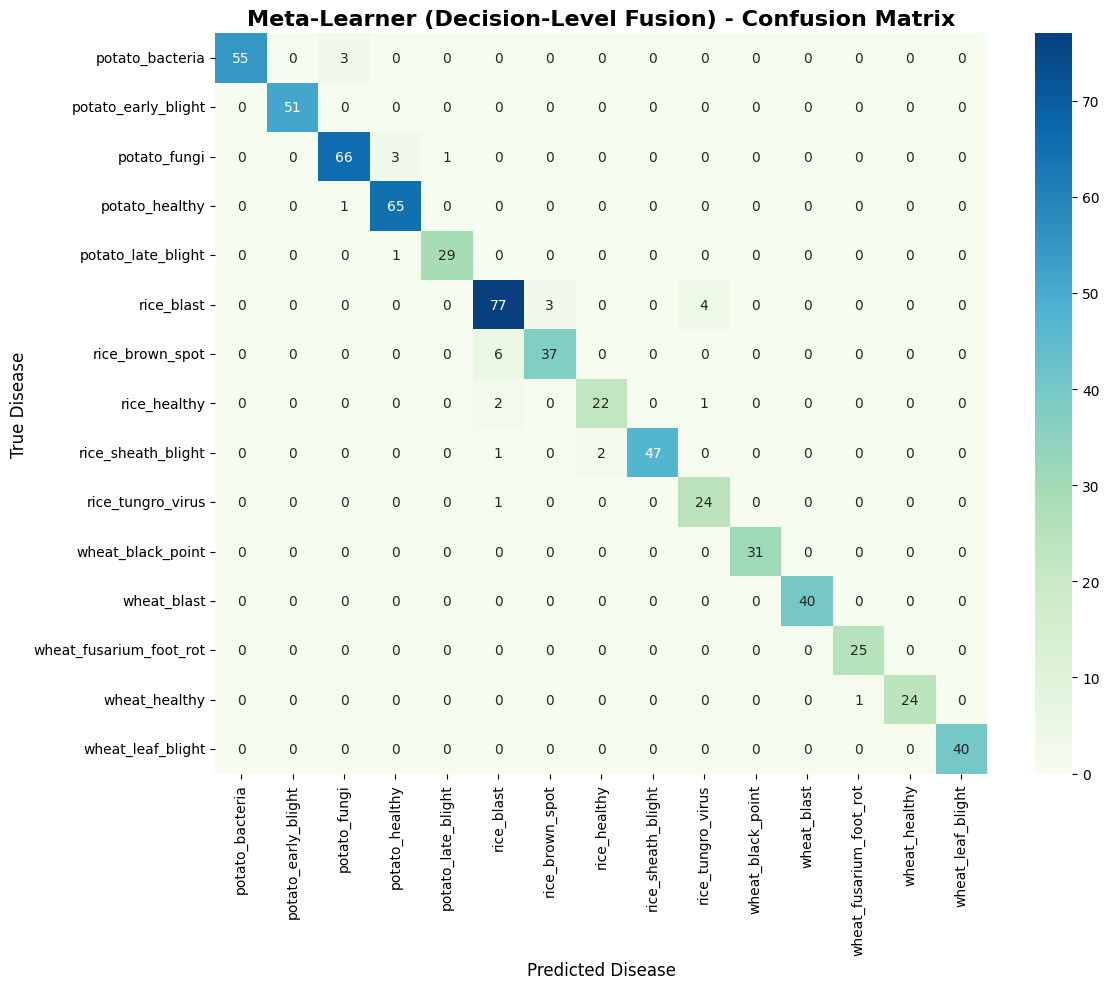

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam for the Meta-Learner (Boss Model)...")

# 1. Evaluate on the Test Set arrays we generated earlier
print("\n📊 Evaluating Boss Model on unseen Test Set...")
test_loss_meta, test_acc_meta = meta_model.evaluate(X_test_meta, y_test_true, verbose=1)
print(f"\n🏆 Official Meta-Learner Test Accuracy: {test_acc_meta * 100:.2f}%")

# 2. Generate Predictions
print("🔍 Generating detailed predictions...")
predictions_meta = meta_model.predict(X_test_meta, verbose=0)
y_pred_meta = np.argmax(predictions_meta, axis=1)
class_names = list(test_generator.class_indices.keys())

# 3. Print Classification Report
print("\n--- Thesis Documentation: Meta-Learner Classification Report ---")
print(classification_report(y_test_true, y_pred_meta, target_names=class_names))

# 4. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_meta = confusion_matrix(y_test_true, y_pred_meta)
# Using a Blue-Green color map for the Meta-Learner
sns.heatmap(cm_meta, annot=True, fmt='d', cmap='GnBu', xticklabels=class_names, yticklabels=class_names)
plt.title('Meta-Learner (Decision-Level Fusion) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the final folder
cm_path_meta = os.path.join(r"D:\00_Thesis_Final_Models", "MetaLearner_Boss_Confusion_Matrix.png")
plt.savefig(cm_path_meta)
print(f"✅ Confusion Matrix saved to {cm_path_meta}")
plt.show()

In [4]:
import os
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🧠 1. Rebuilding EfficientNetB0 skeleton and loading weights...")
base_eff = EfficientNetB0(weights=None, include_top=False, input_shape=(224, 224, 3))
x_eff = GlobalAveragePooling2D()(base_eff.output)
x_eff = BatchNormalization()(x_eff)
x_eff = Dense(256, activation='relu')(x_eff)
x_eff = Dropout(0.4)(x_eff)
preds_eff = Dense(15, activation='softmax')(x_eff)

model_eff = Model(inputs=base_eff.input, outputs=preds_eff)
model_eff.load_weights(os.path.join(weights_dir, "EfficientNetB0_Fresh_Phase2_FineTuned.h5"))
print("✅ EfficientNetB0 Loaded.")

print("\n🔍 2. Asking EfficientNet for its answers (Level 0)...")
pred_train_eff = model_eff.predict(train_generator, verbose=1)
pred_val_eff = model_eff.predict(val_generator, verbose=1)
pred_test_eff = model_eff.predict(test_generator, verbose=1)

print("\n🔗 3. Stitching DenseNet and EfficientNet answers together...")
# We use the pred_train_dense variables that are already in your RAM!
X_train_meta_2 = np.concatenate((pred_train_dense, pred_train_eff), axis=1)
X_val_meta_2 = np.concatenate((pred_val_dense, pred_val_eff), axis=1)
X_test_meta_2 = np.concatenate((pred_test_dense, pred_test_eff), axis=1)
print("Shape of Boss 2 Meta-Train Data:", X_train_meta_2.shape)

print("\n🧠 4. Building Boss Model 2 (DenseNet + EfficientNet)...")
meta_model_2 = Sequential([
    Input(shape=(30,), name="meta2_input"), 
    Dense(64, activation='relu', name="meta2_dense_1"),
    Dropout(0.3, name="meta2_dropout"),
    Dense(15, activation='softmax', name="meta2_output")
])

meta_model_2.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='sparse_categorical_crossentropy', 
                     metrics=['accuracy'])

meta_weights_path_2 = os.path.join(weights_dir, "MetaLearner_Boss2_Weights.h5")
meta_checkpoint_2 = ModelCheckpoint(meta_weights_path_2, save_best_only=True, monitor='val_accuracy', verbose=0)
meta_earlystop_2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\n🚀 5. Training Boss Model 2...")
history_meta_2 = meta_model_2.fit(
    X_train_meta_2, y_train_true,
    validation_data=(X_val_meta_2, y_val_true),
    epochs=50,          
    batch_size=16,      
    callbacks=[meta_checkpoint_2, meta_earlystop_2],
    verbose=1
)

print("\n✅ Boss Model 2 Training Complete!")

🧠 1. Rebuilding EfficientNetB0 skeleton and loading weights...
✅ EfficientNetB0 Loaded.

🔍 2. Asking EfficientNet for its answers (Level 0)...
166/166 [==============================] - 13s 77ms/step

🔗 3. Stitching DenseNet and EfficientNet answers together...
Shape of Boss 2 Meta-Train Data: (5238, 30)

🧠 4. Building Boss Model 2 (DenseNet + EfficientNet)...

🚀 5. Training Boss Model 2...
Epoch 1/50
328/328 [==============================] - 3s 8ms/step - loss: 1.4561 - accuracy: 0.7995 - val_loss: 0.4207 - val_accuracy: 0.9554
Epoch 2/50
328/328 [==============================] - 3s 8ms/step - loss: 0.1744 - accuracy: 0.9910 - val_loss: 0.2088 - val_accuracy: 0.9554
Epoch 3/50
328/328 [==============================] - 3s 8ms/step - loss: 0.0708 - accuracy: 0.9918 - val_loss: 0.2052 - val_accuracy: 0.9554
Epoch 4/50
328/328 [==============================] - 2s 7ms/step - loss: 0.0494 - accuracy: 0.9914 - val_loss: 0.2106 - val_accuracy: 0.9538
Epoch 5/50
328/328 [==================

📝 Initiating Final Exam for Boss Model 2 (DenseNet + EfficientNet)...

📊 Evaluating Boss Model 2 on unseen Test Set...
21/21 [==============================] - 0s 7ms/step - loss: 0.2530 - accuracy: 0.9487

🏆 Official Boss Model 2 Test Accuracy: 94.87%
🔍 Generating detailed predictions...

--- Thesis Documentation: Boss Model 2 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.93      0.96        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.93      0.94      0.94        70
         potato_healthy       0.94      0.98      0.96        66
     potato_late_blight       1.00      0.97      0.98        30
             rice_blast       0.88      0.93      0.90        84
        rice_brown_spot       0.95      0.86      0.90        43
           rice_healthy       0.85      0.88      0.86        25
     rice_sheath_blight       1.00      0.94      0.97    

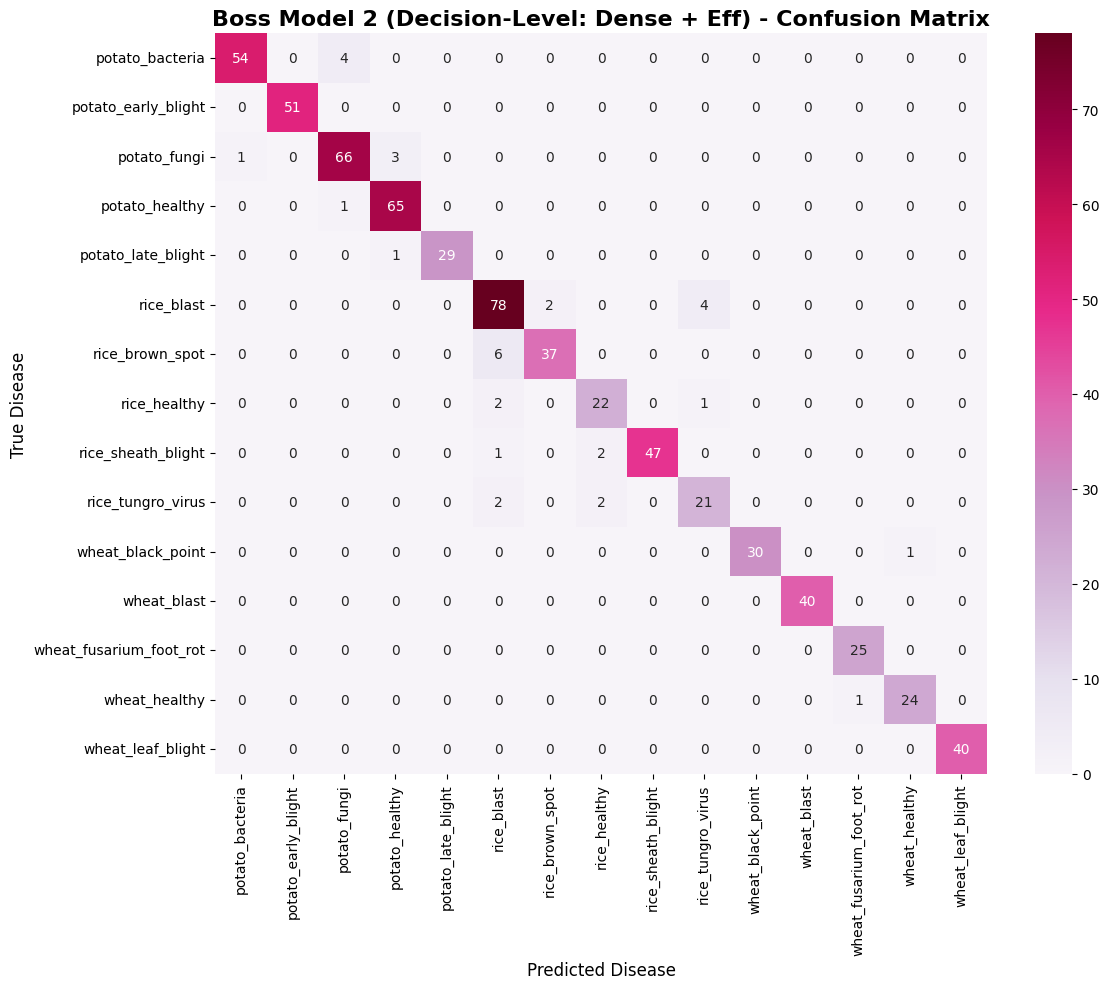

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam for Boss Model 2 (DenseNet + EfficientNet)...")

# 1. Evaluate on the Test Set arrays
print("\n📊 Evaluating Boss Model 2 on unseen Test Set...")
test_loss_meta2, test_acc_meta2 = meta_model_2.evaluate(X_test_meta_2, y_test_true, verbose=1)
print(f"\n🏆 Official Boss Model 2 Test Accuracy: {test_acc_meta2 * 100:.2f}%")

# 2. Generate Predictions
print("🔍 Generating detailed predictions...")
predictions_meta2 = meta_model_2.predict(X_test_meta_2, verbose=0)
y_pred_meta2 = np.argmax(predictions_meta2, axis=1)
class_names = list(test_generator.class_indices.keys())

# 3. Print Classification Report
print("\n--- Thesis Documentation: Boss Model 2 Classification Report ---")
print(classification_report(y_test_true, y_pred_meta2, target_names=class_names))

# 4. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_meta2 = confusion_matrix(y_test_true, y_pred_meta2)
# Using a Purple-Red colormap to distinguish it
sns.heatmap(cm_meta2, annot=True, fmt='d', cmap='PuRd', xticklabels=class_names, yticklabels=class_names)
plt.title('Boss Model 2 (Decision-Level: Dense + Eff) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save to the final folder
cm_path_meta2 = os.path.join(r"D:\00_Thesis_Final_Models", "MetaLearner_Boss2_Confusion_Matrix.png")
plt.savefig(cm_path_meta2)
print(f"✅ Confusion Matrix saved to {cm_path_meta2}")
plt.show()

🔗 1. Stitching MobileNet and EfficientNet answers together...
Shape of Boss 3 Meta-Train Data: (5238, 30)

🧠 2. Building Boss Model 3 (MobileNet + EfficientNet)...

🚀 3. Training Boss Model 3...
Epoch 1/50
328/328 [==============================] - 4s 10ms/step - loss: 1.6717 - accuracy: 0.7026 - val_loss: 0.6593 - val_accuracy: 0.9185
Epoch 2/50
328/328 [==============================] - 3s 9ms/step - loss: 0.3645 - accuracy: 0.9569 - val_loss: 0.3061 - val_accuracy: 0.9231
Epoch 3/50
328/328 [==============================] - 3s 8ms/step - loss: 0.2057 - accuracy: 0.9586 - val_loss: 0.2845 - val_accuracy: 0.9215
Epoch 4/50
328/328 [==============================] - 3s 8ms/step - loss: 0.1897 - accuracy: 0.9576 - val_loss: 0.2759 - val_accuracy: 0.9200
Epoch 5/50
328/328 [==============================] - 3s 8ms/step - loss: 0.1783 - accuracy: 0.9565 - val_loss: 0.2745 - val_accuracy: 0.9246
Epoch 6/50
328/328 [==============================] - 3s 8ms/step - loss: 0.1680 - accuracy: 0

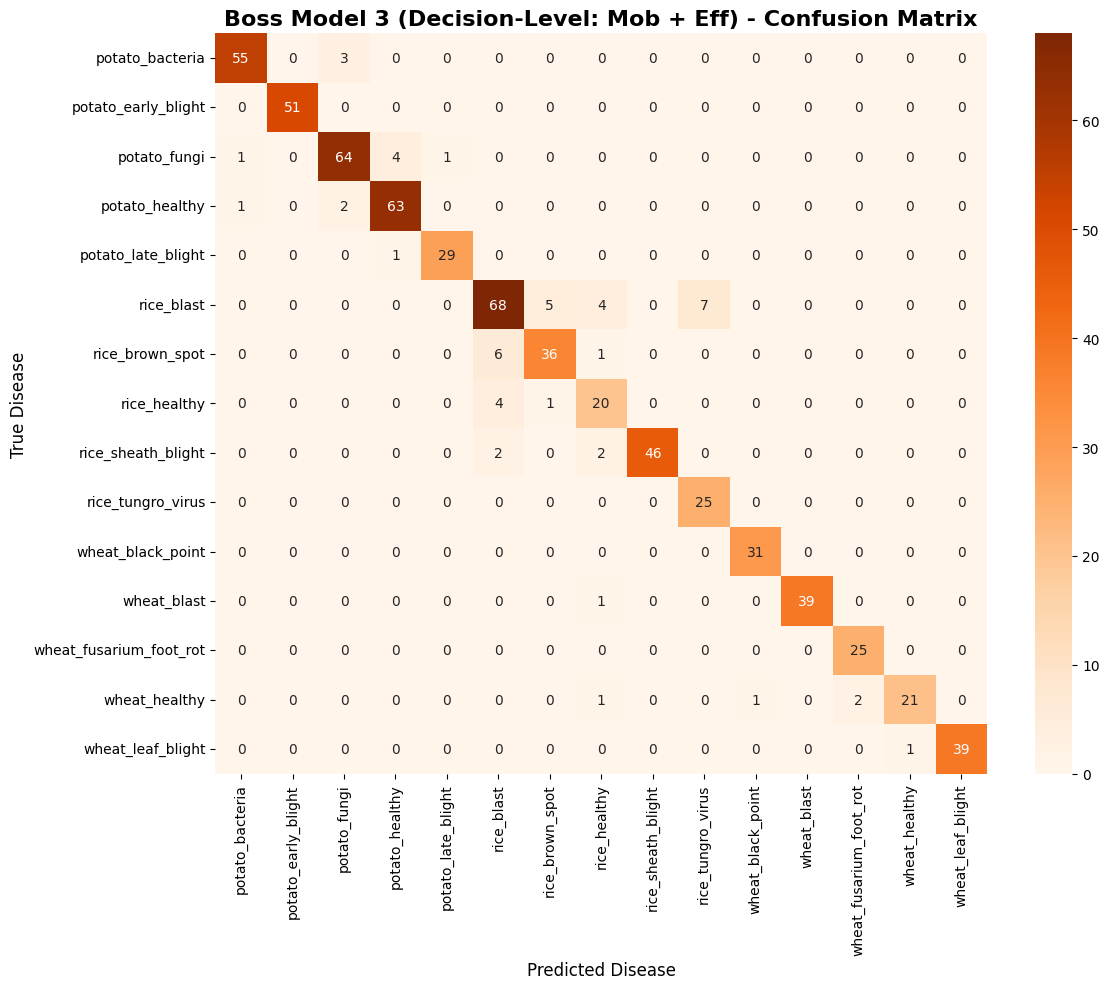

In [6]:
import os
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("🔗 1. Stitching MobileNet and EfficientNet answers together...")
# Using the predictions already safely stored in your RAM!
X_train_meta_3 = np.concatenate((pred_train_mob, pred_train_eff), axis=1)
X_val_meta_3 = np.concatenate((pred_val_mob, pred_val_eff), axis=1)
X_test_meta_3 = np.concatenate((pred_test_mob, pred_test_eff), axis=1)
print("Shape of Boss 3 Meta-Train Data:", X_train_meta_3.shape)

print("\n🧠 2. Building Boss Model 3 (MobileNet + EfficientNet)...")
meta_model_3 = Sequential([
    Input(shape=(30,), name="meta3_input"), 
    Dense(64, activation='relu', name="meta3_dense_1"),
    Dropout(0.3, name="meta3_dropout"),
    Dense(15, activation='softmax', name="meta3_output")
])

meta_model_3.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='sparse_categorical_crossentropy', 
                     metrics=['accuracy'])

# Setup simple callbacks to save the Boss
weights_dir = r"D:\00_Thesis_Final_Models"
meta_weights_path_3 = os.path.join(weights_dir, "MetaLearner_Boss3_Weights.h5")
meta_checkpoint_3 = ModelCheckpoint(meta_weights_path_3, save_best_only=True, monitor='val_accuracy', verbose=0)
meta_earlystop_3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("\n🚀 3. Training Boss Model 3...")
history_meta_3 = meta_model_3.fit(
    X_train_meta_3, y_train_true,
    validation_data=(X_val_meta_3, y_val_true),
    epochs=50,          
    batch_size=16,      
    callbacks=[meta_checkpoint_3, meta_earlystop_3],
    verbose=1
)

print("\n✅ Boss Model 3 Training Complete!")

# ==========================================
# FINAL EXAM FOR BOSS MODEL 3
# ==========================================
print("\n📝 4. Initiating Final Exam for Boss Model 3...")
test_loss_meta3, test_acc_meta3 = meta_model_3.evaluate(X_test_meta_3, y_test_true, verbose=1)
print(f"\n🏆 Official Boss Model 3 Test Accuracy: {test_acc_meta3 * 100:.2f}%")

print("🔍 Generating detailed predictions...")
predictions_meta3 = meta_model_3.predict(X_test_meta_3, verbose=0)
y_pred_meta3 = np.argmax(predictions_meta3, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\n--- Thesis Documentation: Boss Model 3 Classification Report ---")
print(classification_report(y_test_true, y_pred_meta3, target_names=class_names))

plt.figure(figsize=(12, 10))
cm_meta3 = confusion_matrix(y_test_true, y_pred_meta3)
# Using an Orange colormap for this specific combo
sns.heatmap(cm_meta3, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Boss Model 3 (Decision-Level: Mob + Eff) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path_meta3 = os.path.join(weights_dir, "MetaLearner_Boss3_Confusion_Matrix.png")
plt.savefig(cm_path_meta3)
print(f"✅ Confusion Matrix saved to {cm_path_meta3}")
plt.show()